# RQ1 + RQ2 — Audited dataset, mT5 and RemBERT extension


In [14]:
import os, re, json, unicodedata, textwrap, warnings
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
import torch
from datasets import load_dataset
from scipy.stats import mannwhitneyu, pearsonr, spearmanr, kendalltau
from sklearn.metrics.pairwise import cosine_similarity
from tqdm.auto import tqdm
from transformers import AutoTokenizer, AutoModel, MT5EncoderModel

try:
    import sentencepiece as spm
    import google.protobuf
except ImportError as exc:
    raise ImportError(
        "mT5 requires sentencepiece and protobuf. Run in this notebook: "
        "%pip install sentencepiece protobuf, then restart the kernel."
    ) from exc

warnings.filterwarnings("ignore")
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

PURPLE = "#534AB7"
TEAL = "#0F6E56"
CORAL = "#993C1D"
AMBER = "#854F0B"
GRAY = "#5F5E5A"
LBLUE = "#378ADD"
PINK = "#D1495B"
GREEN = "#2A9D8F"

MODEL_COLORS = {
    "mbert": TEAL, "xlmr": LBLUE, "mt5": GREEN,
    "rembert": PINK, "ro_bert": PURPLE, "robert": AMBER,
}
FAMILY_COLOR = {"Multilingual": TEAL, "Monolingual": PURPLE}

plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.grid": True, "grid.alpha": 0.3,
    "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 11, "axes.titlesize": 12, "axes.labelsize": 10,
})

for folder in ["figures_rq1_audited", "figures_rq2_audited", "analysis_outputs_audited"]:
    Path(folder).mkdir(exist_ok=True)
FIG_FOLDER_RQ1 = "figures_rq1_audited"
FIG_FOLDER_RQ2 = "figures_rq2_audited"
ANALYSIS_FOLDER = "analysis_outputs_audited"


# Dataset load and audit

This version defaults to the complete official `test` split of
`klusai/diacritics-ro` (approximately 8,000 records) and keeps `id` and
`source`. Set `USE_OFFICIAL_TEST = False` only to reproduce the legacy local
sample. In that case the seed and exact IDs are exported.

The audit is deliberately stricter than simple accent removal:

1. normalize each string to NFC;
2. standardize Romanian cedilla characters (`ş/ţ/Ş/Ţ`) to comma-below;
3. inspect and normalize whitespace separately;
4. strip only Romanian diacritics using an explicit mapping;
5. require exact equality;
6. exclude and report punctuation, whitespace, spelling, and other differences.


In [15]:
USE_OFFICIAL_TEST = True  # Set to True to use the official test split from the Hugging Face dataset; False to use a local sample CSV.
DATASET_ID = "klusai/diacritics-ro"
DATASET_SPLIT = "test"
LOCAL_SAMPLE = Path("diacritics_dataset_small.csv")
SAMPLE_SEED = 42

CEDILLA_TO_COMMA = str.maketrans({"ş": "ș", "ţ": "ț", "Ş": "Ș", "Ţ": "Ț"})
STRIP_RO = str.maketrans({
    "ă": "a", "â": "a", "î": "i", "ș": "s", "ț": "t",
    "Ă": "A", "Â": "A", "Î": "I", "Ș": "S", "Ț": "T",
})
ROMANIAN_DIACRITICS = set("ăâîșțĂÂÎȘȚ")
LEGACY_CEDILLA = set("şţŞŢ")
COMMON_PUNCT = set(".,;:!?-–—()[]{}\"'„”«»…/%+*=<>@#&_")

def nfc(text):
    return unicodedata.normalize("NFC", str(text))

def standardize_romanian(text):
    return nfc(text).translate(CEDILLA_TO_COMMA)

def normalize_whitespace(text):
    # All Unicode whitespace, including NBSP, becomes one ASCII space.
    return re.sub(r"\s+", " ", str(text), flags=re.UNICODE).strip()

def strip_romanian_diacritics(text):
    # Explicit Romanian-only mapping: no generic NFKD accent deletion.
    return str(text).translate(STRIP_RO)

def char_inventory(text):
    text = str(text)
    return {
        "n_chars": len(text),
        "n_nfd_codepoints": sum(unicodedata.combining(c) != 0 for c in unicodedata.normalize("NFD", text)),
        "n_combining_in_raw": sum(unicodedata.combining(c) != 0 for c in text),
        "n_legacy_cedilla": sum(c in LEGACY_CEDILLA for c in text),
        "n_nbsp": text.count("\u00a0"),
        "n_unusual_punct": sum(
            unicodedata.category(c).startswith("P") and c not in COMMON_PUNCT for c in text
        ),
        "is_nfc": unicodedata.is_normalized("NFC", text),
        "is_nfd": unicodedata.is_normalized("NFD", text),
    }

def punctuation_signature(text):
    return "".join(c for c in str(text) if unicodedata.category(c).startswith("P"))

def alnum_signature(text):
    return "".join(c.casefold() for c in str(text) if c.isalnum())

def audit_pair(row):
    raw_input = str(row["input"])
    raw_target = str(row["target"])
    input_std = standardize_romanian(raw_input)
    target_std = standardize_romanian(raw_target)
    stripped_target_pre_ws = strip_romanian_diacritics(target_std)
    input_clean = normalize_whitespace(input_std)
    target_clean = normalize_whitespace(target_std)
    stripped_target = normalize_whitespace(strip_romanian_diacritics(target_clean))

    whitespace_difference = stripped_target_pre_ws != input_std and stripped_target == input_clean
    exact_after_cleaning = stripped_target == input_clean

    if exact_after_cleaning and not whitespace_difference:
        reason = "valid"
    elif whitespace_difference:
        reason = "whitespace"
    elif punctuation_signature(stripped_target) != punctuation_signature(input_clean):
        reason = "punctuation"
    elif alnum_signature(stripped_target) != alnum_signature(input_clean):
        reason = "spelling"
    else:
        reason = "other"

    before_i = char_inventory(raw_input)
    before_t = char_inventory(raw_target)
    after_i = char_inventory(input_clean)
    after_t = char_inventory(target_clean)
    return pd.Series({
        "input_clean": input_clean,
        "target_clean": target_clean,
        "stripped_target": stripped_target,
        "exact_after_cleaning": exact_after_cleaning,
        "whitespace_difference": whitespace_difference,
        "audit_reason": reason,
        "is_valid_pair": reason == "valid",
        **{f"input_before_{k}": v for k, v in before_i.items()},
        **{f"target_before_{k}": v for k, v in before_t.items()},
        **{f"input_after_{k}": v for k, v in after_i.items()},
        **{f"target_after_{k}": v for k, v in after_t.items()},
    })

if USE_OFFICIAL_TEST:
    official = load_dataset(DATASET_ID, split=DATASET_SPLIT)
    raw_df = official.to_pandas()[["id", "source", "input", "target"]].copy()
    dataset_provenance = f"{DATASET_ID}:{DATASET_SPLIT}"
else:
    raw_df = pd.read_csv(LOCAL_SAMPLE)
    raw_df = raw_df.rename(columns={"no_diacritics": "input", "diacritics": "target"})
    if "source" not in raw_df:
        raw_df["source"] = "unknown_local_sample"
    raw_df = raw_df[["id", "source", "input", "target"]].copy()
    dataset_provenance = f"local_sample:{LOCAL_SAMPLE}; seed={SAMPLE_SEED}"
    pd.Series(raw_df["id"], name="id").to_csv(
        f"{ANALYSIS_FOLDER}/retained_sample_ids_seed_{SAMPLE_SEED}.csv", index=False
    )

audit_cols = raw_df.apply(audit_pair, axis=1)
audited = pd.concat([raw_df.reset_index(drop=True), audit_cols], axis=1)

inventory_fields = [
    "n_chars", "n_nfd_codepoints", "n_combining_in_raw",
    "n_legacy_cedilla", "n_nbsp", "n_unusual_punct",
]
inventory_rows = []
for stage in ["before", "after"]:
    for side in ["input", "target"]:
        inventory_rows.append({
            "stage": stage,
            "side": side,
            **{
                field: int(audited[f"{side}_{stage}_{field}"].sum())
                for field in inventory_fields
            },
            "n_not_nfc": int((~audited[f"{side}_{stage}_is_nfc"]).sum()),
            "n_is_nfd": int(audited[f"{side}_{stage}_is_nfd"].sum()),
        })
inventory_df = pd.DataFrame(inventory_rows)

exclusion_summary = (
    audited.groupby(["source", "audit_reason"], dropna=False)
    .size().rename("n_pairs").reset_index()
)
excluded = audited[~audited["is_valid_pair"]].copy()
clean_audited = audited[audited["is_valid_pair"]].copy()
clean = clean_audited.copy()
clean["text_nodiac"] = clean["input_clean"]
clean["text_diac"] = clean["target_clean"]
clean["n_chars"] = clean["text_nodiac"].str.len()
clean["n_words"] = clean["text_nodiac"].str.split().str.len()
clean["n_diac_restored"] = clean["text_diac"].apply(
    lambda s: sum(c in ROMANIAN_DIACRITICS for c in str(s))
)
length_ok = (clean["n_words"] >= 3) & (clean["n_words"] <= 250)
length_excluded = clean[~length_ok].copy()
length_excluded["audit_reason"] = "length_outside_3_250_words"
clean = clean[length_ok].copy().reset_index(drop=True)

audited.to_csv(f"{ANALYSIS_FOLDER}/dataset_audit_all_pairs.csv", index=False)
excluded.to_csv(f"{ANALYSIS_FOLDER}/dataset_audit_excluded_pairs.csv", index=False)
length_excluded.to_csv(f"{ANALYSIS_FOLDER}/dataset_length_excluded_pairs.csv", index=False)
clean[["id", "source", "text_nodiac", "text_diac", "n_words", "n_diac_restored"]].to_csv(
    f"{ANALYSIS_FOLDER}/dataset_clean_pairs_used.csv", index=False
)
inventory_df.to_csv(f"{ANALYSIS_FOLDER}/dataset_unicode_inventory.csv", index=False)
exclusion_summary.to_csv(f"{ANALYSIS_FOLDER}/dataset_exclusions_by_source.csv", index=False)

print("Dataset provenance:", dataset_provenance)
print(f"Raw pairs: {len(audited):,}")
print(f"Valid pairs used after audit and length filter: {len(clean):,}")
print(f"Audit-excluded pairs: {len(excluded):,}")
print(f"Additional length-excluded pairs: {len(length_excluded):,}")
display(exclusion_summary)
display(inventory_df)

df_all = audited
df_filtered = clean
TEXTS_NODIAC = df_filtered["text_nodiac"].tolist()
TEXTS_DIAC = df_filtered["text_diac"].tolist()
N = len(df_filtered)


Dataset provenance: klusai/diacritics-ro:test
Raw pairs: 8,000
Valid pairs used after audit and length filter: 2,049
Audit-excluded pairs: 5,781
Additional length-excluded pairs: 170


,source,audit_reason,n_pairs
0,crawler,other,13
1,crawler,punctuation,14
2,crawler,spelling,2950
3,crawler,valid,1020
4,crawler,whitespace,3
5,dlrlc,other,32
6,dlrlc,spelling,2769
7,dlrlc,valid,1199


,stage,side,n_chars,n_nfd_codepoints,n_combining_in_raw,n_legacy_cedilla,n_nbsp,n_unusual_punct,n_not_nfc,n_is_nfd
0,before,input,953414,40044,0,3917,9,736,0,2419
1,before,target,953384,55852,0,0,12,736,0,596
2,after,input,953414,40044,0,0,0,736,0,2419
3,after,target,953384,55852,0,0,0,736,0,596


# Six tokenizer and encoder models


In [16]:
MODEL_SPECS = {
    "mbert": {
        "display": "mBERT", "family": "Multilingual",
        "hf_id": "bert-base-multilingual-cased", "architecture": "encoder",
    },
    "xlmr": {
        "display": "XLM-R", "family": "Multilingual",
        "hf_id": "FacebookAI/xlm-roberta-base", "architecture": "encoder",
    },
    "mt5": {
        "display": "mT5", "family": "Multilingual",
        "hf_id": "google/mt5-base", "architecture": "mt5_encoder",
    },
    "rembert": {
        "display": "RemBERT", "family": "Multilingual",
        "hf_id": "google/rembert", "architecture": "encoder",
    },
    "ro_bert": {
        "display": "RO-BERT", "family": "Monolingual",
        "hf_id": "dumitrescustefan/bert-base-romanian-cased-v1", "architecture": "encoder",
    },
    "robert": {
        "display": "RoBERT", "family": "Monolingual",
        "hf_id": "readerbench/RoBERT-base", "architecture": "encoder",
    },
}

MODEL_DISPLAY = {k: v["display"] for k, v in MODEL_SPECS.items()}
MODEL_FAMILY = {k: v["family"] for k, v in MODEL_SPECS.items()}
MODEL_ORDER = ["mbert", "xlmr", "mt5", "rembert", "ro_bert", "robert"]
TOKENIZERS = {
    tag: AutoTokenizer.from_pretrained(
        spec["hf_id"],
        use_fast=False if tag == "mt5" else True,
    )
    for tag, spec in MODEL_SPECS.items()
}

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

def load_analysis_model(spec):
    if spec["architecture"] == "mt5_encoder":
        return MT5EncoderModel.from_pretrained(spec["hf_id"])
    return AutoModel.from_pretrained(spec["hf_id"])

MODELS = {
    tag: load_analysis_model(spec).to(DEVICE).eval()
    for tag, spec in MODEL_SPECS.items()
}

for tag, tokenizer in TOKENIZERS.items():
    config = MODELS[tag].config
    n_layers = getattr(config, "num_hidden_layers", getattr(config, "num_layers", None))
    print(f"{MODEL_DISPLAY[tag]:10} -> {MODEL_SPECS[tag]['hf_id']}")
    print(f"  vocab size: {tokenizer.vocab_size}")
    print(f"  unk token : {tokenizer.unk_token}")
    print(f"  encoder layers: {n_layers}")


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 2745.54it/s]
[transformers] BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 3531.66it/s]
[transformers] XLMRobertaModel LOAD REPORT from: FacebookAI/xlm-roberta-base
Key                       | Status

mBERT      -> bert-base-multilingual-cased
  vocab size: 119547
  unk token : [UNK]
  encoder layers: 12
XLM-R      -> FacebookAI/xlm-roberta-base
  vocab size: 250002
  unk token : <unk>
  encoder layers: 12
mT5        -> google/mt5-base
  vocab size: 250100
  unk token : <unk>
  encoder layers: 12
RemBERT    -> google/rembert
  vocab size: 250300
  unk token : [UNK]
  encoder layers: 32
RO-BERT    -> dumitrescustefan/bert-base-romanian-cased-v1
  vocab size: 50000
  unk token : [UNK]
  encoder layers: 12
RoBERT     -> readerbench/RoBERT-base
  vocab size: 37788
  unk token : [UNK]
  encoder layers: 12


In [17]:
def hf_tokenize(sentence, tokenizer):
    old_max_len = tokenizer.model_max_length
    try:
        tokenizer.model_max_length = int(1e9)
        encoded = tokenizer(
            str(sentence), add_special_tokens=False, truncation=False,
            return_attention_mask=False, return_token_type_ids=False, verbose=False,
        )
        return tokenizer.convert_ids_to_tokens(encoded["input_ids"])
    finally:
        tokenizer.model_max_length = old_max_len

def count_unk(tokens, tokenizer):
    return 0 if tokenizer.unk_token is None else sum(t == tokenizer.unk_token for t in tokens)

def clean_subword_token(tok):
    return tok.replace("##", "").replace("▁", "").replace("Ġ", "").strip()

def single_char_rate(tokens, tokenizer):
    cleaned = [
        clean_subword_token(t) for t in tokens
        if t not in tokenizer.all_special_tokens and clean_subword_token(t)
    ]
    return sum(len(t) == 1 for t in cleaned) / len(cleaned) if cleaned else 0.0

def encoder_hidden(outputs):
    # AutoModel encoders expose last_hidden_state; MT5EncoderModel does too.
    return outputs.last_hidden_state

def get_sentence_embedding(sentence, tag, layer=-1):
    tokenizer, model = TOKENIZERS[tag], MODELS[tag]
    encoded = tokenizer(
        str(sentence), return_tensors="pt", truncation=True, max_length=512,
        return_special_tokens_mask=True,
    )
    special_mask = encoded.pop("special_tokens_mask").to(DEVICE)
    encoded = {k: v.to(DEVICE) for k, v in encoded.items()}
    with torch.no_grad():
        outputs = model(**encoded, output_hidden_states=True, return_dict=True)
    hidden = outputs.hidden_states[layer]
    attention = encoded["attention_mask"].bool()
    content_mask = attention & ~special_mask.bool()
    if not content_mask.any():
        content_mask = attention
    first_content = int(content_mask[0].nonzero(as_tuple=False)[0].item())
    anchor_index = first_content if tag == "mt5" else 0
    anchor = hidden[0, anchor_index]
    mean = hidden[0][content_mask[0]].mean(dim=0)
    return {
        "anchor": anchor.detach().cpu().numpy(),
        "mean": mean.detach().cpu().numpy(),
    }

def get_target_word_embedding(sentence, target_start, target_end, tag):
    tokenizer, model = TOKENIZERS[tag], MODELS[tag]
    encoded = tokenizer(
        str(sentence), return_tensors="pt", return_offsets_mapping=True,
        truncation=True, max_length=512, add_special_tokens=True,
    )
    offsets = encoded.pop("offset_mapping")[0].tolist()
    indices = [
        i for i, (start, end) in enumerate(offsets)
        if start != end and not (end <= target_start or start >= target_end)
    ]
    if not indices:
        return None
    encoded = {k: v.to(DEVICE) for k, v in encoded.items()}
    with torch.no_grad():
        hidden = encoder_hidden(model(**encoded, return_dict=True))[0]
    return hidden[indices].mean(dim=0).detach().cpu().numpy()

def get_layer_embeddings(sentence, tag):
    tokenizer, model = TOKENIZERS[tag], MODELS[tag]
    encoded = tokenizer(
        str(sentence), return_tensors="pt", truncation=True, max_length=512,
        return_special_tokens_mask=True,
    )
    special_mask = encoded.pop("special_tokens_mask").to(DEVICE)
    encoded = {k: v.to(DEVICE) for k, v in encoded.items()}
    with torch.no_grad():
        outputs = model(**encoded, output_hidden_states=True, return_dict=True)
    attention = encoded["attention_mask"].bool()
    content_mask = attention & ~special_mask.bool()
    if not content_mask.any():
        content_mask = attention
    first_content = int(content_mask[0].nonzero(as_tuple=False)[0].item())
    anchor_index = first_content if tag == "mt5" else 0
    return [h[0, anchor_index].detach().cpu().numpy() for h in outputs.hidden_states]


# RQ1 — Tokenization metrics


In [18]:
rows = []
for i, row in tqdm(df_filtered.iterrows(), total=N, desc="Tokenization"):
    sent_nd, sent_d = row["text_nodiac"], row["text_diac"]
    n_words, n_diac = row["n_words"], row["n_diac_restored"]
    for tag, tokenizer in TOKENIZERS.items():
        toks_nd, toks_d = hf_tokenize(sent_nd, tokenizer), hf_tokenize(sent_d, tokenizer)
        cnt_nd, cnt_d = len(toks_nd), len(toks_d)
        rows.append({
            "sent_idx": i, "id": row["id"], "source": row["source"],
            "model": tag, "family": MODEL_FAMILY[tag],
            "n_words": n_words, "n_diac": n_diac,
            "tokens_nd": cnt_nd, "fertility_nd": cnt_nd / max(n_words, 1),
            "unk_nd": count_unk(toks_nd, tokenizer), "scr_nd": single_char_rate(toks_nd, tokenizer),
            "tokens_d": cnt_d, "fertility_d": cnt_d / max(n_words, 1),
            "unk_d": count_unk(toks_d, tokenizer), "scr_d": single_char_rate(toks_d, tokenizer),
            "delta_tokens": cnt_d - cnt_nd,
            "inflation": (cnt_d - cnt_nd) / max(cnt_nd, 1),
        })
df = pd.DataFrame(rows)
df.to_csv(f"{ANALYSIS_FOLDER}/rq1_per_sentence_tokenization.csv", index=False)
print(f"Records: {len(df):,} ({N:,} pairs x {len(MODEL_ORDER)} models)")


Tokenization: 100%|██████████| 2049/2049 [00:10<00:00, 199.09it/s]


Records: 12,294 (2,049 pairs x 6 models)


In [19]:
RQ1_METRICS = {
    "avg_tokens_nd": ("tokens_nd", "mean"), "avg_tokens_d": ("tokens_d", "mean"),
    "avg_fert_nd": ("fertility_nd", "mean"), "avg_fert_d": ("fertility_d", "mean"),
    "avg_unk_nd": ("unk_nd", "mean"), "avg_unk_d": ("unk_d", "mean"),
    "avg_scr_nd": ("scr_nd", "mean"), "avg_scr_d": ("scr_d", "mean"),
    "avg_delta": ("delta_tokens", "mean"), "avg_inflation": ("inflation", "mean"),
}
summary = df.groupby("model").agg(**RQ1_METRICS).round(6).reset_index()
summary["display"] = summary["model"].map(MODEL_DISPLAY)
summary["family"] = summary["model"].map(MODEL_FAMILY)
summary.to_csv(f"{ANALYSIS_FOLDER}/rq1_summary_tokenizers.csv", index=False)

summary_by_source = (
    df.groupby(["source", "model"]).agg(**RQ1_METRICS).round(6).reset_index()
)
summary_by_source["display"] = summary_by_source["model"].map(MODEL_DISPLAY)
summary_by_source["family"] = summary_by_source["model"].map(MODEL_FAMILY)
summary_by_source.to_csv(f"{ANALYSIS_FOLDER}/rq1_summary_by_source.csv", index=False)
display(summary)
display(summary_by_source)


,model,avg_tokens_nd,avg_tokens_d,avg_fert_nd,avg_fert_d,avg_unk_nd,avg_unk_d,avg_scr_nd,avg_scr_d,avg_delta,avg_inflation,display,family
0,mbert,34.744754,36.330405,2.056963,2.163213,0.185944,0.185944,0.241630,0.284017,1.585652,0.051985,mBERT,Multilingual
1,mt5,34.536359,37.242557,2.023571,2.178666,0.000000,0.000000,0.269012,0.280704,2.706198,0.078446,mT5,Multilingual
2,rembert,30.855539,31.455344,1.826764,1.875925,0.000000,0.000000,0.251316,0.265096,0.599805,0.026568,RemBERT,Multilingual
3,ro_bert,27.027330,25.958516,1.616603,1.556605,0.072230,0.072230,0.246455,0.243634,-1.068814,-0.036614,RO-BERT,Monolingual
4,robert,29.618350,29.226940,1.737421,1.713905,0.000000,0.000000,0.261434,0.261521,-0.391410,-0.013058,RoBERT,Monolingual
5,xlmr,30.415325,31.928258,1.806501,1.899218,0.000000,0.000000,0.242759,0.254357,1.512933,0.051644,XLM-R,Multilingual


,source,model,avg_tokens_nd,avg_tokens_d,avg_fert_nd,avg_fert_d,avg_unk_nd,avg_unk_d,avg_scr_nd,avg_scr_d,avg_delta,avg_inflation,display,family
0,crawler,mbert,45.563195,46.899899,1.891047,1.953875,0.346815,0.346815,0.227564,0.254900,1.336704,0.033600,mBERT,Multilingual
1,crawler,mt5,45.847321,49.013145,1.910026,2.038462,0.000000,0.000000,0.258040,0.266116,3.165824,0.069092,mT5,Multilingual
2,crawler,rembert,40.484328,40.798787,1.683015,1.702365,0.000000,0.000000,0.235255,0.247926,0.314459,0.011429,RemBERT,Multilingual
3,crawler,ro_bert,35.384226,33.982811,1.487094,1.432383,0.111223,0.111223,0.228271,0.223869,-1.401416,-0.036407,RO-BERT,Monolingual
4,crawler,robert,39.441860,38.964611,1.651686,1.633212,0.000000,0.000000,0.248256,0.246247,-0.477250,-0.011210,RoBERT,Monolingual
5,crawler,xlmr,40.028311,41.592518,1.672211,1.737218,0.000000,0.000000,0.230799,0.239229,1.564206,0.039195,XLM-R,Multilingual
6,dlrlc,mbert,24.650943,26.468868,2.211765,2.358530,0.035849,0.035849,0.254753,0.311184,1.817925,0.069138,mBERT,Multilingual
7,dlrlc,mt5,23.983019,26.260377,2.129511,2.309480,0.000000,0.000000,0.279250,0.294315,2.277358,0.087173,mT5,Multilingual
8,dlrlc,rembert,21.871698,22.737736,1.960884,2.037860,0.000000,0.000000,0.266301,0.281117,0.866038,0.040693,RemBERT,Multilingual
9,dlrlc,ro_bert,19.230189,18.471698,1.737437,1.672506,0.035849,0.035849,0.263422,0.262075,-0.758491,-0.036807,RO-BERT,Monolingual


## Vocabulary overlap, including source-stratified results


In [20]:
vocab_stats = []
for source, tag in tqdm(
    [(s, t) for s in ["ALL", *sorted(df_filtered["source"].dropna().unique())] for t in MODEL_ORDER],
    desc="Vocabulary overlap",
):
    tokenizer = TOKENIZERS[tag]
    data = df_filtered if source == "ALL" else df_filtered[df_filtered["source"] == source]
    all_nd, all_d, jaccards = [], [], []
    for s_nd, s_d in zip(data["text_nodiac"], data["text_diac"]):
        t_nd, t_d = hf_tokenize(s_nd, tokenizer), hf_tokenize(s_d, tokenizer)
        all_nd.extend(t_nd); all_d.extend(t_d)
        union = set(t_nd) | set(t_d)
        jaccards.append(len(set(t_nd) & set(t_d)) / len(union) if union else 1.0)
    v_nd, v_d = set(all_nd), set(all_d)
    union = v_nd | v_d
    vocab_stats.append({
        "source": source, "model": tag, "display": MODEL_DISPLAY[tag],
        "family": MODEL_FAMILY[tag], "vocab_nd": len(v_nd), "vocab_d": len(v_d),
        "shared": len(v_nd & v_d), "only_nd": len(v_nd - v_d), "only_d": len(v_d - v_nd),
        "overlap_pct": 100 * len(v_nd & v_d) / len(union) if union else 100.0,
        "mean_jaccard": np.mean(jaccards), "std_jaccard": np.std(jaccards),
    })
vocab_df = pd.DataFrame(vocab_stats)
vocab_df.to_csv(f"{ANALYSIS_FOLDER}/rq1_vocab_overlap_by_source.csv", index=False)
display(vocab_df)


Vocabulary overlap: 100%|██████████| 18/18 [00:11<00:00,  1.57it/s]


,source,model,display,family,vocab_nd,vocab_d,shared,only_nd,only_d,overlap_pct,mean_jaccard,std_jaccard
0,ALL,mbert,mBERT,Multilingual,6238,5957,5465,773,492,81.203566,0.649130,0.182105
1,ALL,xlmr,XLM-R,Multilingual,7708,7425,6468,1240,957,74.645124,0.642287,0.186379
2,ALL,mt5,mT5,Multilingual,7848,7331,6510,1338,821,75.095167,0.648722,0.182829
3,ALL,rembert,RemBERT,Multilingual,8034,7936,6756,1278,1180,73.323204,0.631216,0.190890
4,ALL,ro_bert,RO-BERT,Monolingual,10078,11481,7878,2200,3603,57.583510,0.625932,0.193509
5,ALL,robert,RoBERT,Monolingual,8310,9196,6698,1612,2498,61.972613,0.658081,0.185319
6,crawler,mbert,mBERT,Multilingual,5251,5072,4609,642,463,80.661533,0.654762,0.154868
7,crawler,xlmr,XLM-R,Multilingual,6217,6073,5234,983,839,74.178005,0.648263,0.157337
8,crawler,mt5,mT5,Multilingual,6158,5868,5156,1002,712,75.050946,0.653337,0.154841
9,crawler,rembert,RemBERT,Multilingual,6348,6383,5371,977,1012,72.975543,0.634935,0.162849


# RQ1 visualizations


In [ ]:
# RQ1 plots — dynamically support all models in MODEL_ORDER
ordered_summary = summary.set_index("model").loc[MODEL_ORDER]
labels = [MODEL_DISPLAY[m] for m in MODEL_ORDER]
colors = [MODEL_COLORS[m] for m in MODEL_ORDER]
x = np.arange(len(MODEL_ORDER))
w = 0.36

# Figure 1: token-count distributions
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5), sharey=True)
for ax, column, title in [
    (axes[0], "tokens_nd", "Without diacritics"),
    (axes[1], "tokens_d", "With diacritics"),
]:
    values = [df.loc[df["model"] == m, column].values for m in MODEL_ORDER]
    parts = ax.violinplot(values, positions=x, showmedians=True, showextrema=True)
    for body, color in zip(parts["bodies"], colors):
        body.set_facecolor(color); body.set_alpha(0.72); body.set_edgecolor("white")
    parts["cmedians"].set_color("white")
    means = [np.mean(v) for v in values]
    ax.scatter(x, means, c="white", edgecolors=GRAY, zorder=3)
    ax.set_xticks(x); ax.set_xticklabels(labels, rotation=25, ha="right")
    ax.set_title(title); ax.set_ylabel("Tokens per sentence")
fig.suptitle("RQ1 — Token-count distributions on audited pairs")
plt.tight_layout(); plt.savefig(f"{FIG_FOLDER_RQ1}/rq1_fig1_token_distributions.png", dpi=150, bbox_inches="tight"); plt.show()

# Figure 2: fertility
fig, ax = plt.subplots(figsize=(12, 5.5))
b1 = ax.bar(x-w/2, ordered_summary["avg_fert_nd"], w, color=colors, alpha=.9, label="No diacritics")
b2 = ax.bar(x+w/2, ordered_summary["avg_fert_d"], w, color=colors, alpha=.45, hatch="..", label="Diacritics")
ax.bar_label(b1, fmt="%.3f", fontsize=8); ax.bar_label(b2, fmt="%.3f", fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=25, ha="right")
ax.set_ylabel("Subword tokens per whitespace-delimited word"); ax.set_title("RQ1 — Tokenizer fertility")
ax.legend(); plt.tight_layout(); plt.savefig(f"{FIG_FOLDER_RQ1}/rq1_fig2_fertility.png", dpi=150, bbox_inches="tight"); plt.show()

# Figure 3: token inflation
inflation = ordered_summary["avg_inflation"].to_numpy() * 100
fig, ax = plt.subplots(figsize=(11, 5.5))
bars = ax.bar(x, inflation, color=colors, alpha=.85)
ax.axhline(0, color=GRAY, linewidth=1)
ax.bar_label(bars, labels=[f"{v:+.2f}%" for v in inflation], padding=3, fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=25, ha="right")
ax.set_ylabel("Mean token inflation (%)"); ax.set_title("RQ1 — Effect of adding Romanian diacritics on token count")
plt.tight_layout(); plt.savefig(f"{FIG_FOLDER_RQ1}/rq1_fig3_token_inflation.png", dpi=150, bbox_inches="tight"); plt.show()

# Figure 4: UNK and single-character rate
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))
for ax, nd_col, d_col, title, ylabel in [
    (axes[0], "avg_unk_nd", "avg_unk_d", "Unknown-token rate", "Mean [UNK] per sentence"),
    (axes[1], "avg_scr_nd", "avg_scr_d", "Single-character rate", "Proportion of one-character tokens"),
]:
    ax.bar(x-w/2, ordered_summary[nd_col], w, color=colors, alpha=.9, label="No diacritics")
    ax.bar(x+w/2, ordered_summary[d_col], w, color=colors, alpha=.45, hatch="..", label="Diacritics")
    ax.set_xticks(x); ax.set_xticklabels(labels, rotation=25, ha="right")
    ax.set_title(title); ax.set_ylabel(ylabel); ax.legend()
fig.suptitle("RQ1 — Fragmentation diagnostics after dataset audit")
plt.tight_layout(); plt.savefig(f"{FIG_FOLDER_RQ1}/rq1_fig4_unk_scr.png", dpi=150, bbox_inches="tight"); plt.show()

# Figure 5: corpus vocabulary overlap
vocab_all = vocab_df[vocab_df["source"] == "ALL"].set_index("model").loc[MODEL_ORDER]
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
bars = axes[0].bar(x, vocab_all["overlap_pct"], color=colors, alpha=.85)
axes[0].bar_label(bars, fmt="%.1f%%", padding=3, fontsize=8)
axes[0].set_xticks(x); axes[0].set_xticklabels(labels, rotation=25, ha="right")
axes[0].set_ylabel("Jaccard overlap of corpus token-type sets (%)"); axes[0].set_title("Corpus vocabulary overlap")
bars = axes[1].bar(x, vocab_all["mean_jaccard"], color=colors, alpha=.85)
axes[1].bar_label(bars, fmt="%.3f", padding=3, fontsize=8)
axes[1].set_xticks(x); axes[1].set_xticklabels(labels, rotation=25, ha="right")
axes[1].set_ylabel("Mean per-sentence Jaccard similarity"); axes[1].set_title("Per-sentence vocabulary overlap")
fig.suptitle("RQ1 — Vocabulary reuse across diacritic conditions")
plt.tight_layout(); plt.savefig(f"{FIG_FOLDER_RQ1}/rq1_fig5_vocab_overlap.png", dpi=150, bbox_inches="tight"); plt.show()

# Figure 6: source-stratified token inflation (appendix)
source_plot = summary_by_source.copy()
source_plot["inflation_pct"] = source_plot["avg_inflation"] * 100
source_plot["display"] = source_plot["model"].map(MODEL_DISPLAY)
fig, ax = plt.subplots(figsize=(13, 6))
sns.barplot(data=source_plot, x="display", y="inflation_pct", hue="source", order=labels, ax=ax)
ax.axhline(0, color=GRAY, linewidth=1)
ax.set_xlabel("Model"); ax.set_ylabel("Mean token inflation (%)")
ax.set_title("RQ1 appendix — Token inflation by dataset source")
ax.tick_params(axis="x", rotation=25); ax.legend(title="Source")
plt.tight_layout(); plt.savefig(f"{FIG_FOLDER_RQ1}/rq1_fig6_inflation_by_source.png", dpi=150, bbox_inches="tight"); plt.show()


# RQ2 — Contextual embedding robustness

`Anchor` preserves CLS/<s> for BERT/RoBERTa-like models. mT5 has no CLS token, so its anchor is the first lexical token. Mean pooling is the primary architecture-neutral metric.


In [21]:
EMBEDDING_MAX_PAIRS = None  # set an integer for a documented pilot run
embedding_data = df_filtered if EMBEDDING_MAX_PAIRS is None else df_filtered.head(EMBEDDING_MAX_PAIRS)
sim_rows = []
for tag in MODEL_ORDER:
    for i, row in tqdm(embedding_data.iterrows(), total=len(embedding_data), desc=MODEL_DISPLAY[tag]):
        emb_d = get_sentence_embedding(row["text_diac"], tag)
        emb_nd = get_sentence_embedding(row["text_nodiac"], tag)
        cos_anchor = float(cosine_similarity(
            emb_d["anchor"].reshape(1, -1), emb_nd["anchor"].reshape(1, -1)
        )[0, 0])
        cos_mean = float(cosine_similarity(
            emb_d["mean"].reshape(1, -1), emb_nd["mean"].reshape(1, -1)
        )[0, 0])
        sim_rows.append({
            "sent_idx": i, "id": row["id"], "source": row["source"],
            "model": tag, "family": MODEL_FAMILY[tag],
            "n_words": row["n_words"], "n_diac": row["n_diac_restored"],
            "cos_anchor": cos_anchor, "cos_mean": cos_mean,
            "dist_anchor": 1 - cos_anchor, "dist_mean": 1 - cos_mean,
        })
sim_df = pd.DataFrame(sim_rows)
sim_df.to_csv(f"{ANALYSIS_FOLDER}/rq2_sentence_cosine_sims.csv", index=False)


RoBERT: 100%|██████████| 2049/2049 [04:24<00:00,  7.76it/s]


## Word-level minimal-pair analysis


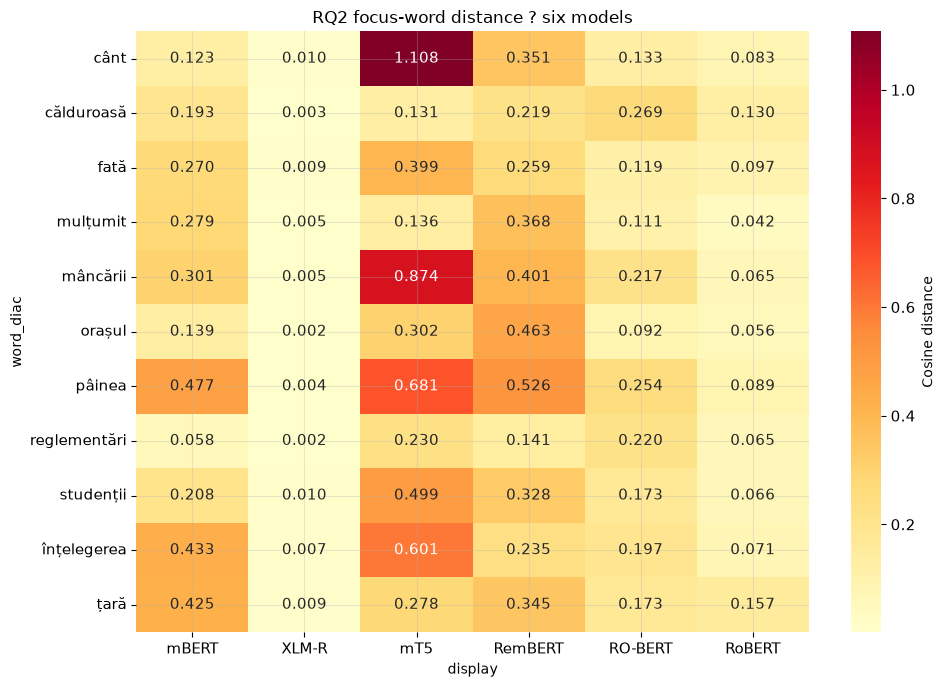

In [27]:
MINIMAL_PAIRS = [
    ('O fată frumoasă merge spre bibliotecă.',
     'O fata frumoasa merge spre biblioteca.',
     'fată', 'fata'),

    ('Eu cânt la pian în fiecare seară.',
     'Eu cant la pian in fiecare seara.',
     'cânt', 'cant'),

    ('România este o țară frumoasă.',
     'Romania este o tara frumoasa.',
     'țară', 'tara'),

    ('Pâinea proaspătă mirosea îmbietor.',
     'Painea proaspata mirosea imbietor.',
     'pâinea', 'painea'),

    ('Studenții și-au finalizat tezele de licență.',
     'Studentii si-au finalizat tezele de licenta.',
     'studenții', 'studentii'),

    ('Calitatea mâncării este excepțională.',
     'Calitatea mancarii este exceptionala.',
     'mâncării', 'mancarii'),

    ('Sunt mulțumit de produsul achiziționat.',
     'Sunt multumit de produsul achizitionat.',
     'mulțumit', 'multumit'),

    ('Orașul vechi are multe clădiri istorice.',
     'Orasul vechi are multe cladiri istorice.',
     'orașul', 'orasul'),

    ('Guvernul a adoptat noi reglementări privind mediul.',
     'Guvernul a adoptat noi reglementari privind mediul.',
     'reglementări', 'reglementari'),

    ('Înțelegerea dintre cele două țări a fost semnată.',
     'Intelegerea dintre cele doua tari a fost semnata.',
     'înțelegerea', 'intelegerea'),

    ('Vara aceasta a fost extrem de călduroasă.',
     'Vara aceasta a fost extrem de calduroasa.',
     'călduroasă', 'calduroasa'),
]
word_rows=[]
for sent_d,sent_nd,word_d,word_nd in MINIMAL_PAIRS:
    start_d=sent_d.lower().find(word_d.lower()); start_nd=sent_nd.lower().find(word_nd.lower())
    for tag in MODEL_ORDER:
        emb_d=get_target_word_embedding(sent_d,start_d,start_d+len(word_d),tag)
        emb_nd=get_target_word_embedding(sent_nd,start_nd,start_nd+len(word_nd),tag)
        distance=np.nan if emb_d is None or emb_nd is None else 1-float(cosine_similarity(emb_d.reshape(1,-1),emb_nd.reshape(1,-1))[0,0])
        word_rows.append({'word_diac':word_d,'word_nodiac':word_nd,'model':tag,'display':MODEL_DISPLAY[tag],'family':MODEL_FAMILY[tag],'cos_dist':distance})
word_df=pd.DataFrame(word_rows)
word_df.to_csv(f'{ANALYSIS_FOLDER}/rq2_focus_word_distances.csv',index=False)
pivot=word_df.pivot(index='word_diac',columns='display',values='cos_dist')[[MODEL_DISPLAY[m] for m in MODEL_ORDER]]
fig,ax=plt.subplots(figsize=(10,7)); sns.heatmap(pivot,annot=True,fmt='.3f',cmap='YlOrRd',ax=ax,cbar_kws={'label':'Cosine distance'})
ax.set_title('Focus-word cosine distance (diac vs no-diac):  higher = more sensitive'); plt.tight_layout(); plt.savefig(f'{FIG_FOLDER_RQ2}/rq2_focus_word_six_models.png',dpi=150,bbox_inches='tight'); plt.show()


## Layer-wise analysis with architecture-specific depth


RoBERT layers: 100%|██████████| 50/50 [00:07<00:00,  6.60it/s]


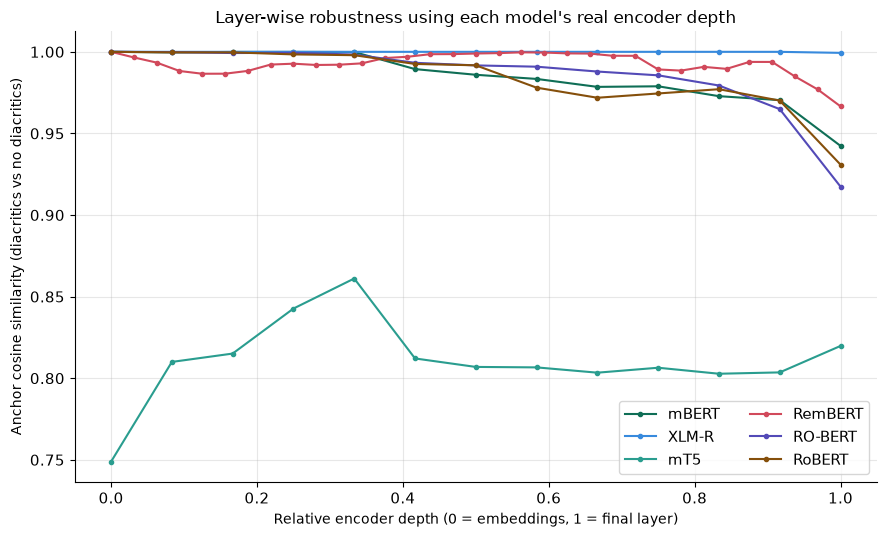

In [23]:
N_LAYER_SUBSET = min(50, len(embedding_data))
layer_sim_store = {}
layer_depths = {}

for tag in MODEL_ORDER:
    sums = None
    for _, row in tqdm(
        embedding_data.head(N_LAYER_SUBSET).iterrows(), total=N_LAYER_SUBSET,
        desc=f"{MODEL_DISPLAY[tag]} layers",
    ):
        layers_d = get_layer_embeddings(row["text_diac"], tag)
        layers_nd = get_layer_embeddings(row["text_nodiac"], tag)
        pair_sims = np.array([
            float(cosine_similarity(a.reshape(1, -1), b.reshape(1, -1))[0, 0])
            for a, b in zip(layers_d, layers_nd)
        ])
        sums = pair_sims if sums is None else sums + pair_sims
    layer_sim_store[tag] = sums / N_LAYER_SUBSET
    layer_depths[tag] = len(layer_sim_store[tag]) - 1

layer_long = pd.DataFrame([
    {
        "model": tag, "display": MODEL_DISPLAY[tag],
        "layer_index": i, "relative_depth": i / max(len(sims) - 1, 1),
        "cosine_similarity": value,
    }
    for tag, sims in layer_sim_store.items()
    for i, value in enumerate(sims)
])
layer_long.to_csv(f"{ANALYSIS_FOLDER}/rq2_layer_wise_sims_long.csv", index=False)

fig, ax = plt.subplots(figsize=(9, 5.5))
for tag in MODEL_ORDER:
    sub = layer_long[layer_long["model"] == tag]
    ax.plot(sub["relative_depth"], sub["cosine_similarity"], marker="o", ms=3,
            color=MODEL_COLORS[tag], label=MODEL_DISPLAY[tag])
ax.set_xlabel("Relative encoder depth (0 = embeddings, 1 = final layer)")
ax.set_ylabel("Anchor cosine similarity (diacritics vs no diacritics)")
ax.set_title("Layer-wise robustness using each model's real encoder depth")
ax.legend(ncol=2)
plt.tight_layout()
plt.savefig(f"{FIG_FOLDER_RQ2}/rq2_layerwise_relative_depth.png", dpi=150, bbox_inches="tight")
plt.show()


## Cross-model agreement on difficult sentence pairs


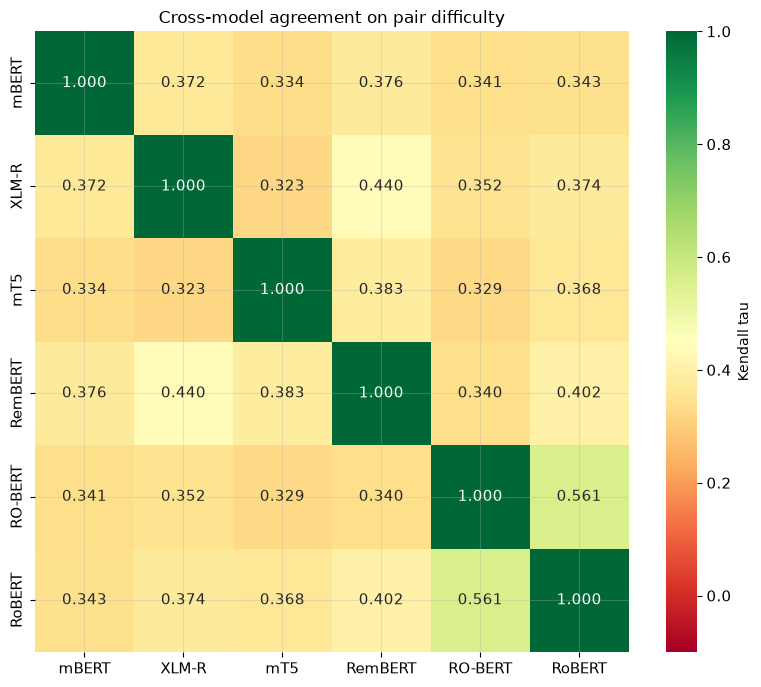

In [24]:
rank_matrix=pd.DataFrame({MODEL_DISPLAY[tag]:sim_df[sim_df['model']==tag].sort_values('sent_idx')['cos_anchor'].rank(ascending=True).values for tag in MODEL_ORDER})
labels=[MODEL_DISPLAY[tag] for tag in MODEL_ORDER]; tau=np.zeros((len(labels),len(labels)))
for i,left in enumerate(labels):
    for j,right in enumerate(labels): tau[i,j]=kendalltau(rank_matrix[left],rank_matrix[right]).statistic
tau_df=pd.DataFrame(tau,index=labels,columns=labels); tau_df.to_csv(f'{ANALYSIS_FOLDER}/rq2_cross_model_kendall_tau.csv')
fig,ax=plt.subplots(figsize=(8,7)); sns.heatmap(tau_df,annot=True,fmt='.3f',cmap='RdYlGn',vmin=-.1,vmax=1,ax=ax,cbar_kws={'label':'Kendall tau'})
ax.set_title('Cross-model agreement on pair difficulty'); plt.tight_layout(); plt.savefig(f'{FIG_FOLDER_RQ2}/rq2_cross_model_kendall_tau.png',dpi=150,bbox_inches='tight'); plt.show()


## Final and source-stratified RQ2 tables


In [25]:
corr_rows, final_rows = [], []
for tag in MODEL_ORDER:
    sub = sim_df[sim_df["model"] == tag]
    r_p, p_p = pearsonr(sub["n_diac"], sub["cos_anchor"])
    r_s, p_s = spearmanr(sub["n_diac"], sub["cos_anchor"])
    corr_rows.append({
        "model": tag, "display": MODEL_DISPLAY[tag], "family": MODEL_FAMILY[tag],
        "pearson_r": r_p, "pearson_p": p_p, "spearman_r": r_s, "spearman_p": p_s,
    })
    sims = layer_sim_store[tag]
    final_rows.append({
        "Model": MODEL_DISPLAY[tag], "Family": MODEL_FAMILY[tag],
        "Anchor sim mean": sub["cos_anchor"].mean(),
        "Anchor sim std": sub["cos_anchor"].std(),
        "Anchor sim min": sub["cos_anchor"].min(),
        "Mean-pool sim": sub["cos_mean"].mean(),
        "Focus-word dist": word_df.loc[word_df["model"] == tag, "cos_dist"].mean(),
        "Pearson r (density)": r_p,
        "Layer of min sim": int(np.argmin(sims[1:])) + 1,
        "Encoder layers": layer_depths[tag],
    })

corr_df = pd.DataFrame(corr_rows)
final_df = pd.DataFrame(final_rows)
final_df.to_csv(f"{ANALYSIS_FOLDER}/rq2_final_results.csv", index=False)

rq2_by_source = (
    sim_df.groupby(["source", "model"])
    .agg(
        n_pairs=("id", "size"),
        anchor_sim_mean=("cos_anchor", "mean"),
        anchor_sim_std=("cos_anchor", "std"),
        mean_pool_sim_mean=("cos_mean", "mean"),
        mean_pool_sim_std=("cos_mean", "std"),
    ).reset_index()
)
rq2_by_source["display"] = rq2_by_source["model"].map(MODEL_DISPLAY)
rq2_by_source["family"] = rq2_by_source["model"].map(MODEL_FAMILY)
rq2_by_source.to_csv(f"{ANALYSIS_FOLDER}/rq2_summary_by_source.csv", index=False)
display(final_df)
display(rq2_by_source)


,Model,Family,Anchor sim mean,Anchor sim std,Anchor sim min,Mean-pool sim,Focus-word dist,Pearson r (density),Layer of min sim,Encoder layers
0,mBERT,Multilingual,0.953729,0.121014,-0.124586,0.898291,0.466862,-0.279202,12,12
1,XLM-R,Multilingual,0.999197,0.001570,0.956129,0.998989,0.011437,-0.012731,12,12
2,mT5,Multilingual,0.867086,0.224739,-0.202934,0.901549,0.605039,0.005804,10,12
3,RemBERT,Multilingual,0.954999,0.073205,0.240925,0.892436,0.399293,0.027933,32,32
4,RO-BERT,Monolingual,0.925317,0.038564,0.669747,0.916862,0.499911,-0.318440,12,12
5,RoBERT,Monolingual,0.931961,0.035172,0.702230,0.939242,0.365436,-0.294452,12,12


,source,model,n_pairs,anchor_sim_mean,anchor_sim_std,mean_pool_sim_mean,mean_pool_sim_std,display,family
0,crawler,mbert,989,0.936972,0.159841,0.912628,0.077554,mBERT,Multilingual
1,crawler,mt5,989,0.879622,0.216136,0.928105,0.108324,mT5,Multilingual
2,crawler,rembert,989,0.963694,0.041184,0.891928,0.047263,RemBERT,Multilingual
3,crawler,ro_bert,989,0.925096,0.029825,0.915652,0.035858,RO-BERT,Monolingual
4,crawler,robert,989,0.935989,0.024701,0.939310,0.025164,RoBERT,Monolingual
5,crawler,xlmr,989,0.999297,0.000664,0.999118,0.000595,XLM-R,Multilingual
6,dlrlc,mbert,1060,0.969365,0.063068,0.884913,0.097365,mBERT,Multilingual
7,dlrlc,mt5,1060,0.855389,0.231970,0.876772,0.163045,mT5,Multilingual
8,dlrlc,rembert,1060,0.946887,0.092978,0.892910,0.072825,RemBERT,Multilingual
9,dlrlc,ro_bert,1060,0.925524,0.045233,0.917991,0.050004,RO-BERT,Monolingual


## Methodological notes for the revised paper

- **mT5 is encoder-decoder and has no CLS token.** This notebook loads
  `MT5EncoderModel` and compares a common `anchor` representation: the first
  non-special token for every model. Mean pooling is the primary architecture-
  neutral sentence representation and should be emphasized in the paper.
- Layer-wise curves use **relative encoder depth**, because mT5, RemBERT and
  the BERT/RoBERTa models have different numbers of layers.
- The official test split is audited before analysis. Rows with whitespace,
  punctuation, spelling or other non-diacritic differences are excluded and
  retained in an explicit error report.
- Every per-sentence output retains `id` and `source`; appendix summaries are
  exported separately for `crawler` and `dlrlc`.
- If a smaller embedding pilot is required for compute reasons, set
  `EMBEDDING_MAX_PAIRS` and report that exact value. Tokenization still runs on
  the complete audited split.
